In [7]:
import pandas as pd

data = pd.read_excel('dataset.xlsx', sheet_name=None)

display(data.keys())
#display(data)
#print(data.tail())
#print(data.head())
#print(data.shape)

dict_keys(['Data Dictionary', 'ERD', 'orders', 'order_items', 'customers', 'payments', 'products'])

In [9]:
# XLSX TO CSV

import os

output_folder = "clean_csv"
os.makedirs(output_folder, exist_ok=True)

sheets_item = list(data.items())[2:]
for sheet_name, df in sheets_item:

    print(f"Cleaning {sheet_name}...")

    # colonnes en minuscules
    df.columns = df.columns.str.lower()

    # remplacer NaN par vide
    df = df.where(pd.notnull(df), None)

    # forcer colonnes ID en string
    for col in df.columns:
        if "id" in col:
            df[col] = df[col].astype(str)

    # conversion dates automatique si contient 'date' ou 'timestamp'
    for col in df.columns:
        if "date" in col or "timestamp" in col:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # exporter CSV propre
    df.to_csv(f"{output_folder}/{sheet_name.lower()}.csv",
              index=False,
              encoding="utf-8")

print("Export CSV terminé.")

Cleaning orders...
Cleaning order_items...
Cleaning customers...
Cleaning payments...
Cleaning products...
Export CSV terminé.


In [10]:
for sheet_name, df in sheets_item :
    print(sheet_name)
    display(df.columns)

'''df_customers = pd.read_csv('clean_csv/customers.csv')
print(df_customers["customer_id"].duplicated().sum())
print(df_customers.shape)
df_customers = df_customers.drop_duplicates(subset=["customer_id"])
print(df_customers.shape)
print(df_customers["customer_id"].duplicated().sum())'''

orders


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date'],
      dtype='object')

order_items


Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'price',
       'shipping_charges'],
      dtype='object')

customers


...

payments


Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

products


Index(['product_id', 'product_category_name', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

'df_customers = pd.read_csv(\'clean_csv/customers.csv\')\nprint(df_customers["customer_id"].duplicated().sum())\nprint(df_customers.shape)\ndf_customers = df_customers.drop_duplicates(subset=["customer_id"])\nprint(df_customers.shape)\nprint(df_customers["customer_id"].duplicated().sum())'

In [13]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
from io import StringIO

load_dotenv('connexion.env')  # charge .env

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
)

conn = engine.raw_connection()
cursor = conn.cursor()

# Liste ordonnée selon les dépendances FK
ordered_tables = [
    "customers",
    "products",
    "orders",
    "order_items",
    "payments"
]

csv_folder = "clean_csv"
csv_files = [os.path.join(csv_folder, f"{table}.csv") for table in ordered_tables]

# Dictionnaire des clés primaires pour chaque table
primary_keys = {
    "customers": "customer_id",
    "orders": "order_id",
    "order_items": "(order_id, order_item_id)",  # clé composite
    "sellers": "seller_id",
    "products": "product_id",
    "order_payments": "(order_id, payment_sequential)",
    "order_reviews": "review_id"
}

for file in csv_files:
    table_name = os.path.basename(file).replace(".csv", "")
    print(f"Importing {table_name}...")

    # Lire le CSV avec Pandas
    df = pd.read_csv(file)

    # Vérifier si on a une clé primaire définie
    if table_name in primary_keys:
        key = primary_keys[table_name]

        # Gestion clé composite
        if "," in key:
            cols = [c.strip("() ") for c in key.split(",")]
            df = df.drop_duplicates(subset=cols)
        else:
            df = df.drop_duplicates(subset=[key])

    # Convertir NaN → None
    df = df.where(pd.notnull(df), None)

    # Export en mémoire pour COPY
    buffer = StringIO()
    df.to_csv(buffer, index=False, header=True)
    buffer.seek(0)

    # COPY vers PostgreSQL
    cursor.copy_expert(
        f"COPY {table_name} FROM STDIN WITH CSV HEADER DELIMITER ','",
        buffer
    )

conn.commit()
cursor.close()
conn.close()

print("Import PostgreSQL terminé (doublons supprimés).")

Importing customers...


UniqueViolation: FEHLER:  doppelter Schlüsselwert verletzt Unique-Constraint »customers_pkey«
DETAIL:  Schlüssel »(customer_id)=(861eff4711a542e4b93843c6dd7febb0)« existiert bereits.
CONTEXT:  COPY customers, Zeile 2


In [14]:
# REVENUS MENSUEL

df_items = pd.read_sql("SELECT * FROM order_items", engine)
df_orders = pd.read_sql("SELECT order_id, order_purchase_timestamp FROM orders", engine)

df = df_items.merge(df_orders, on="order_id")

df["month"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.to_period("M")

revenue = df.groupby("month")["price"].sum()

print(revenue)

month
2016-09        87.39
2016-10      7301.18
2016-12         8.72
2017-01     16875.62
2017-02     38977.60
2017-03     57704.29
2017-04     52495.01
2017-05     80119.81
2017-06     69924.44
2017-07     86940.14
2017-08     94232.92
2017-09     95997.22
2017-10    105092.94
2017-11    168872.40
2017-12    119633.06
2018-01    157271.53
2018-02    142730.25
2018-03    171913.38
2018-04    163050.29
2018-05    153264.14
2018-06    157552.80
2018-07    163220.81
2018-08    148622.14
2018-09        21.46
Freq: M, Name: price, dtype: float64


In [15]:
#Delivery Delay

df_orders = pd.read_sql("SELECT * FROM orders", engine)

df_orders["delay"] = (

    pd.to_datetime(df_orders["order_estimated_delivery_date"]) -
    pd.to_datetime(df_orders["order_delivered_timestamp"])
)

print(df_orders["delay"].mean())



11 days 04:17:55.957616402


In [17]:
# Quasi-Poisson avec Statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Exemple : nombre de commandes par mois
df_orders["month"] = pd.to_datetime(df_orders["order_purchase_timestamp"]).dt.to_period("M")

monthly = df_orders.groupby("month").size().reset_index(name="orders_count")
monthly["month_index"] = range(len(monthly))

model = smf.glm(
    formula="orders_count ~ month_index + I(month_index**2)",
    data=monthly,
    family=sm.families.Poisson()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           orders_count   No. Observations:                   25
Model:                            GLM   Df Residuals:                       22
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8757.2
Date:                Wed, 18 Mar 2026   Deviance:                       17289.
Time:                        15:05:08   Pearson chi2:                 1.27e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4066    

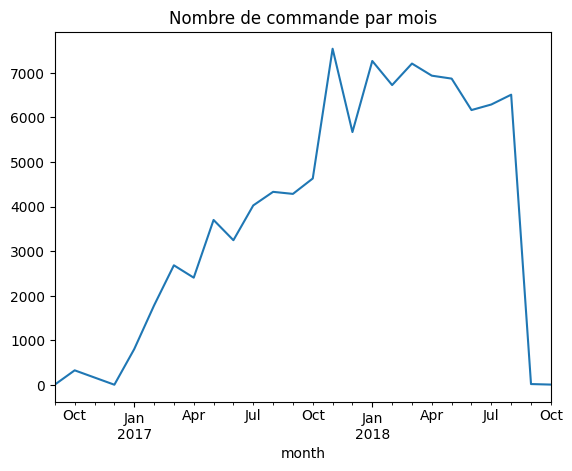

In [21]:
#Nombre de commande dans le temps

import pandas as pd
import matplotlib.pyplot as plt

df_orders = pd.read_sql("SELECT order_purchase_timestamp FROM orders", engine)
df_orders["month"]=pd.to_datetime(df_orders["order_purchase_timestamp"]).dt.to_period("M")

monthly_orders = df_orders.groupby("month").size()
monthly_orders.plot()
plt.title("Nombre de commande par mois")
plt.show()

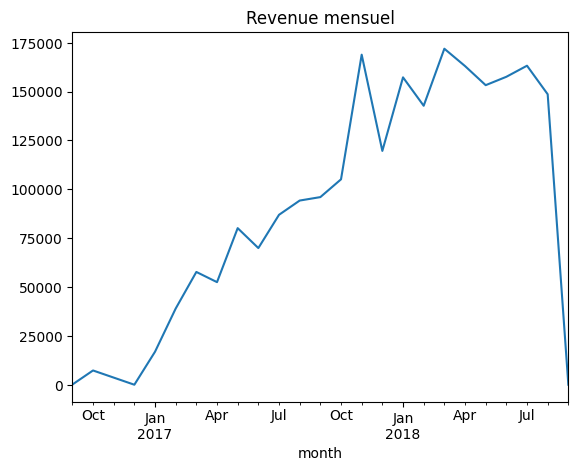

In [24]:
# nombre de revenie par mois

df = pd.read_sql("""
SELECT o.order_purchase_timestamp, oi.price
FROM orders o
JOIN order_items oi USING(order_id)
""", engine)

df["month"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.to_period("M")

revenue = df.groupby("month")["price"].sum()

revenue.plot()
plt.title("Revenue mensuel")
plt.show()

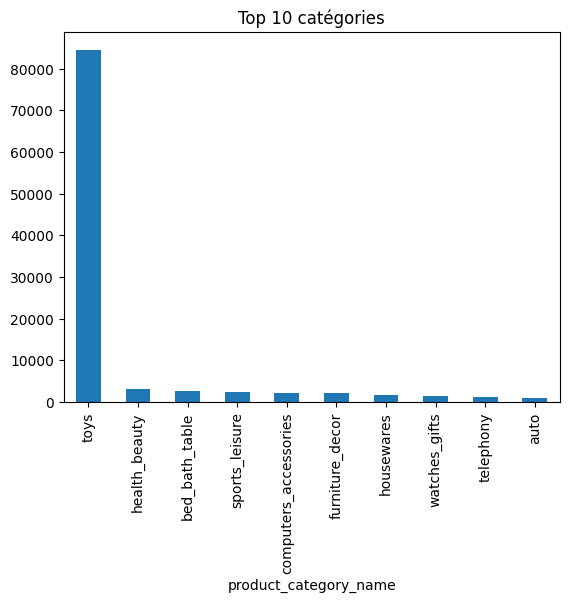

In [25]:
df = pd.read_sql("""
SELECT p.product_category_name
FROM order_items oi
JOIN products p USING(product_id)
""", engine)

top_cat = df["product_category_name"].value_counts().head(10)

top_cat.plot(kind="bar")
plt.title("Top 10 catégories")
plt.show()

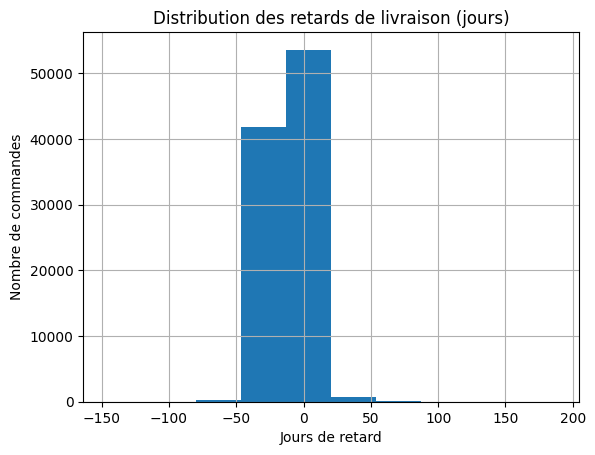

In [35]:
df_orders = pd.read_sql("SELECT * FROM orders", engine)

df_orders["delay"] = (
    pd.to_datetime(df_orders["order_delivered_timestamp"])-
    pd.to_datetime(df_orders["order_estimated_delivery_date"])
)

df_orders["delay_day"] = df_orders["delay"].dt.days

# Histogramm

#print(df_orders.columns)
df_orders["delay_day"].hist()
plt.title("Distribution des retards de livraison")
plt.title("Distribution des retards de livraison (jours)")
plt.xlabel("Jours de retard")
plt.ylabel("Nombre de commandes")
plt.show()

In [37]:
df = pd.read_sql("""
SELECT DATE_TRUNC('month', order_purchase_timestamp) as month,
       COUNT(DISTINCT customer_id) as customers,
       COUNT(order_id) as orders
FROM orders
GROUP BY month
ORDER BY month
""", engine)
print(df)

        month  customers  orders
0  2016-09-01          4       4
1  2016-10-01        321     324
2  2016-12-01          1       1
3  2017-01-01        765     800
4  2017-02-01       1755    1780
5  2017-03-01       2642    2682
6  2017-04-01       2372    2404
7  2017-05-01       3625    3700
8  2017-06-01       3180    3245
9  2017-07-01       3947    4026
10 2017-08-01       4246    4331
11 2017-09-01       4212    4285
12 2017-10-01       4561    4631
13 2017-11-01       7430    7544
14 2017-12-01       5603    5673
15 2018-01-01       7166    7269
16 2018-02-01       6569    6728
17 2018-03-01       7115    7211
18 2018-04-01       6882    6939
19 2018-05-01       6814    6873
20 2018-06-01       6128    6167
21 2018-07-01       6230    6292
22 2018-08-01       6460    6512
23 2018-09-01         14      16
24 2018-10-01          4       4


In [38]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df["month_index"] = range(len(df))

model = smf.glm(
    formula="orders ~ month_index + I(month_index**2)",
    data=df,
    family=sm.families.Poisson()
).fit(scale="X2")  # quasi-poisson

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 orders   No. Observations:                   25
Model:                            GLM   Df Residuals:                       22
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          577.12
Method:                          IRLS   Log-Likelihood:                -15.174
Date:                Wed, 18 Mar 2026   Deviance:                       17289.
Time:                        18:45:24   Pearson chi2:                 1.27e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9485
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4066    

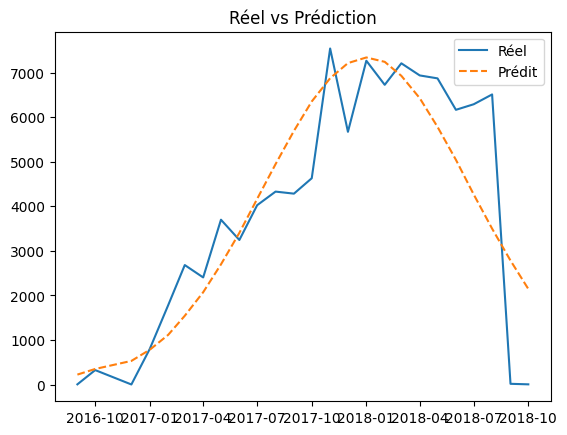

In [42]:
df["pred"] = model.predict(df)

plt.plot(df["month"], df["orders"], label="Réel")
plt.plot(df["month"], df["pred"], label="Prédit", linestyle="--")

plt.legend()
plt.title("Réel vs Prédiction")
plt.show()